In [1]:
%reload_ext autoreload
%autoreload 2
import sys

sys.path.append("../")
from epd_process_funcs import *

from visualisation import *

In [2]:
solar = pd.read_csv("/home/hossein/CICCADA/BOM_NCI/2023/NCI_processed_grouped_all.csv")
solar["time"] = pd.to_datetime(solar["time"])
solar["time"] = solar["time"].dt.tz_localize("utc")
solar["time"] = solar["time"].dt.tz_convert(pytz.FixedOffset(8.5 * 60))
solar["postcode"] = solar["postcode"].astype(int)
solar.rename(
    columns={"surface_global_irradiance": "GHI", "direct_normal_irradiance": "DNI"},
    inplace=True,
)

In [21]:
5068 in solar["postcode"].unique()

True

In [13]:
edp_path = "4) Data/EDP SA 2023 Data"
edp_files = glob(edp_path + "/SA_site_edp_2023_S*.csv")
df = pd.concat(
    [pd.read_csv(i) for i in edp_files if os.path.getsize(i) > 0]
).reset_index(drop=True)

In [14]:
meta_data1 = pd.read_csv(edp_path + "/edp_sites_metadata_sa_postcode.csv")
meta_data2 = pd.read_csv(edp_path + "/edp_sites_metadata59239829.csv")
meta_data2 = meta_data2[meta_data2["state"] == "SA"]
meta_data3 = meta_data2.merge(
    meta_data1[["edp_site_id", "postcode"]], on="edp_site_id", how="left"
)
meta_data3["Srated"] = (
    meta_data3["inverter_ac_rating_kw"] * meta_data3["inverter_count"]
)
meta_data3["Srated"] = meta_data3.apply(
    lambda row: (
        row["inverter_ac_rating_kw"]
        if pd.isna(row["inverter_count"])
        else row["Srated"]
    ),
    axis=1,
)
meta_data2 = (
    meta_data3.groupby(["edp_site_id", "postcode"]).agg({"Srated": "sum"}).reset_index()
)

In [23]:
meta_data1.query('edp_site_id=="S0078"')

,first_date_metadata_received,last_date_metadata_received,edp_site_id,postcode,state,site_timezone,monitoring_hardware,inverter_manufacturer,inverter_model,inverter_ac_rating_kw,...,subarray_tilt,subarray_strings,subarray_modules_per_string,subarray_dc_rating_kw,islandable,has_battery,battery_size_make_model,limit_enabled,limit_amount,limit_applied
9,7/12/2021,30/06/2022,S0078,5068,SA,Australia/Adelaide,SC-23,Solis,Solis-4.6K-2G,4.6,...,25,1.0,16.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
meta_data2.query('edp_site_id=="S0078"')

,edp_site_id,postcode,Srated
9,S0078,5068,4.6


In [6]:
df5 = process_edp(df, meta_data2, 10.5 * 60)

In [36]:
solar["time"].max()

Timestamp('2023-02-28 18:10:00+0830', tz='pytz.FixedOffset(510)')

saved as:  /home/hossein/CICCADA/tests/Figures/Solar_clouds_active_power.jpeg


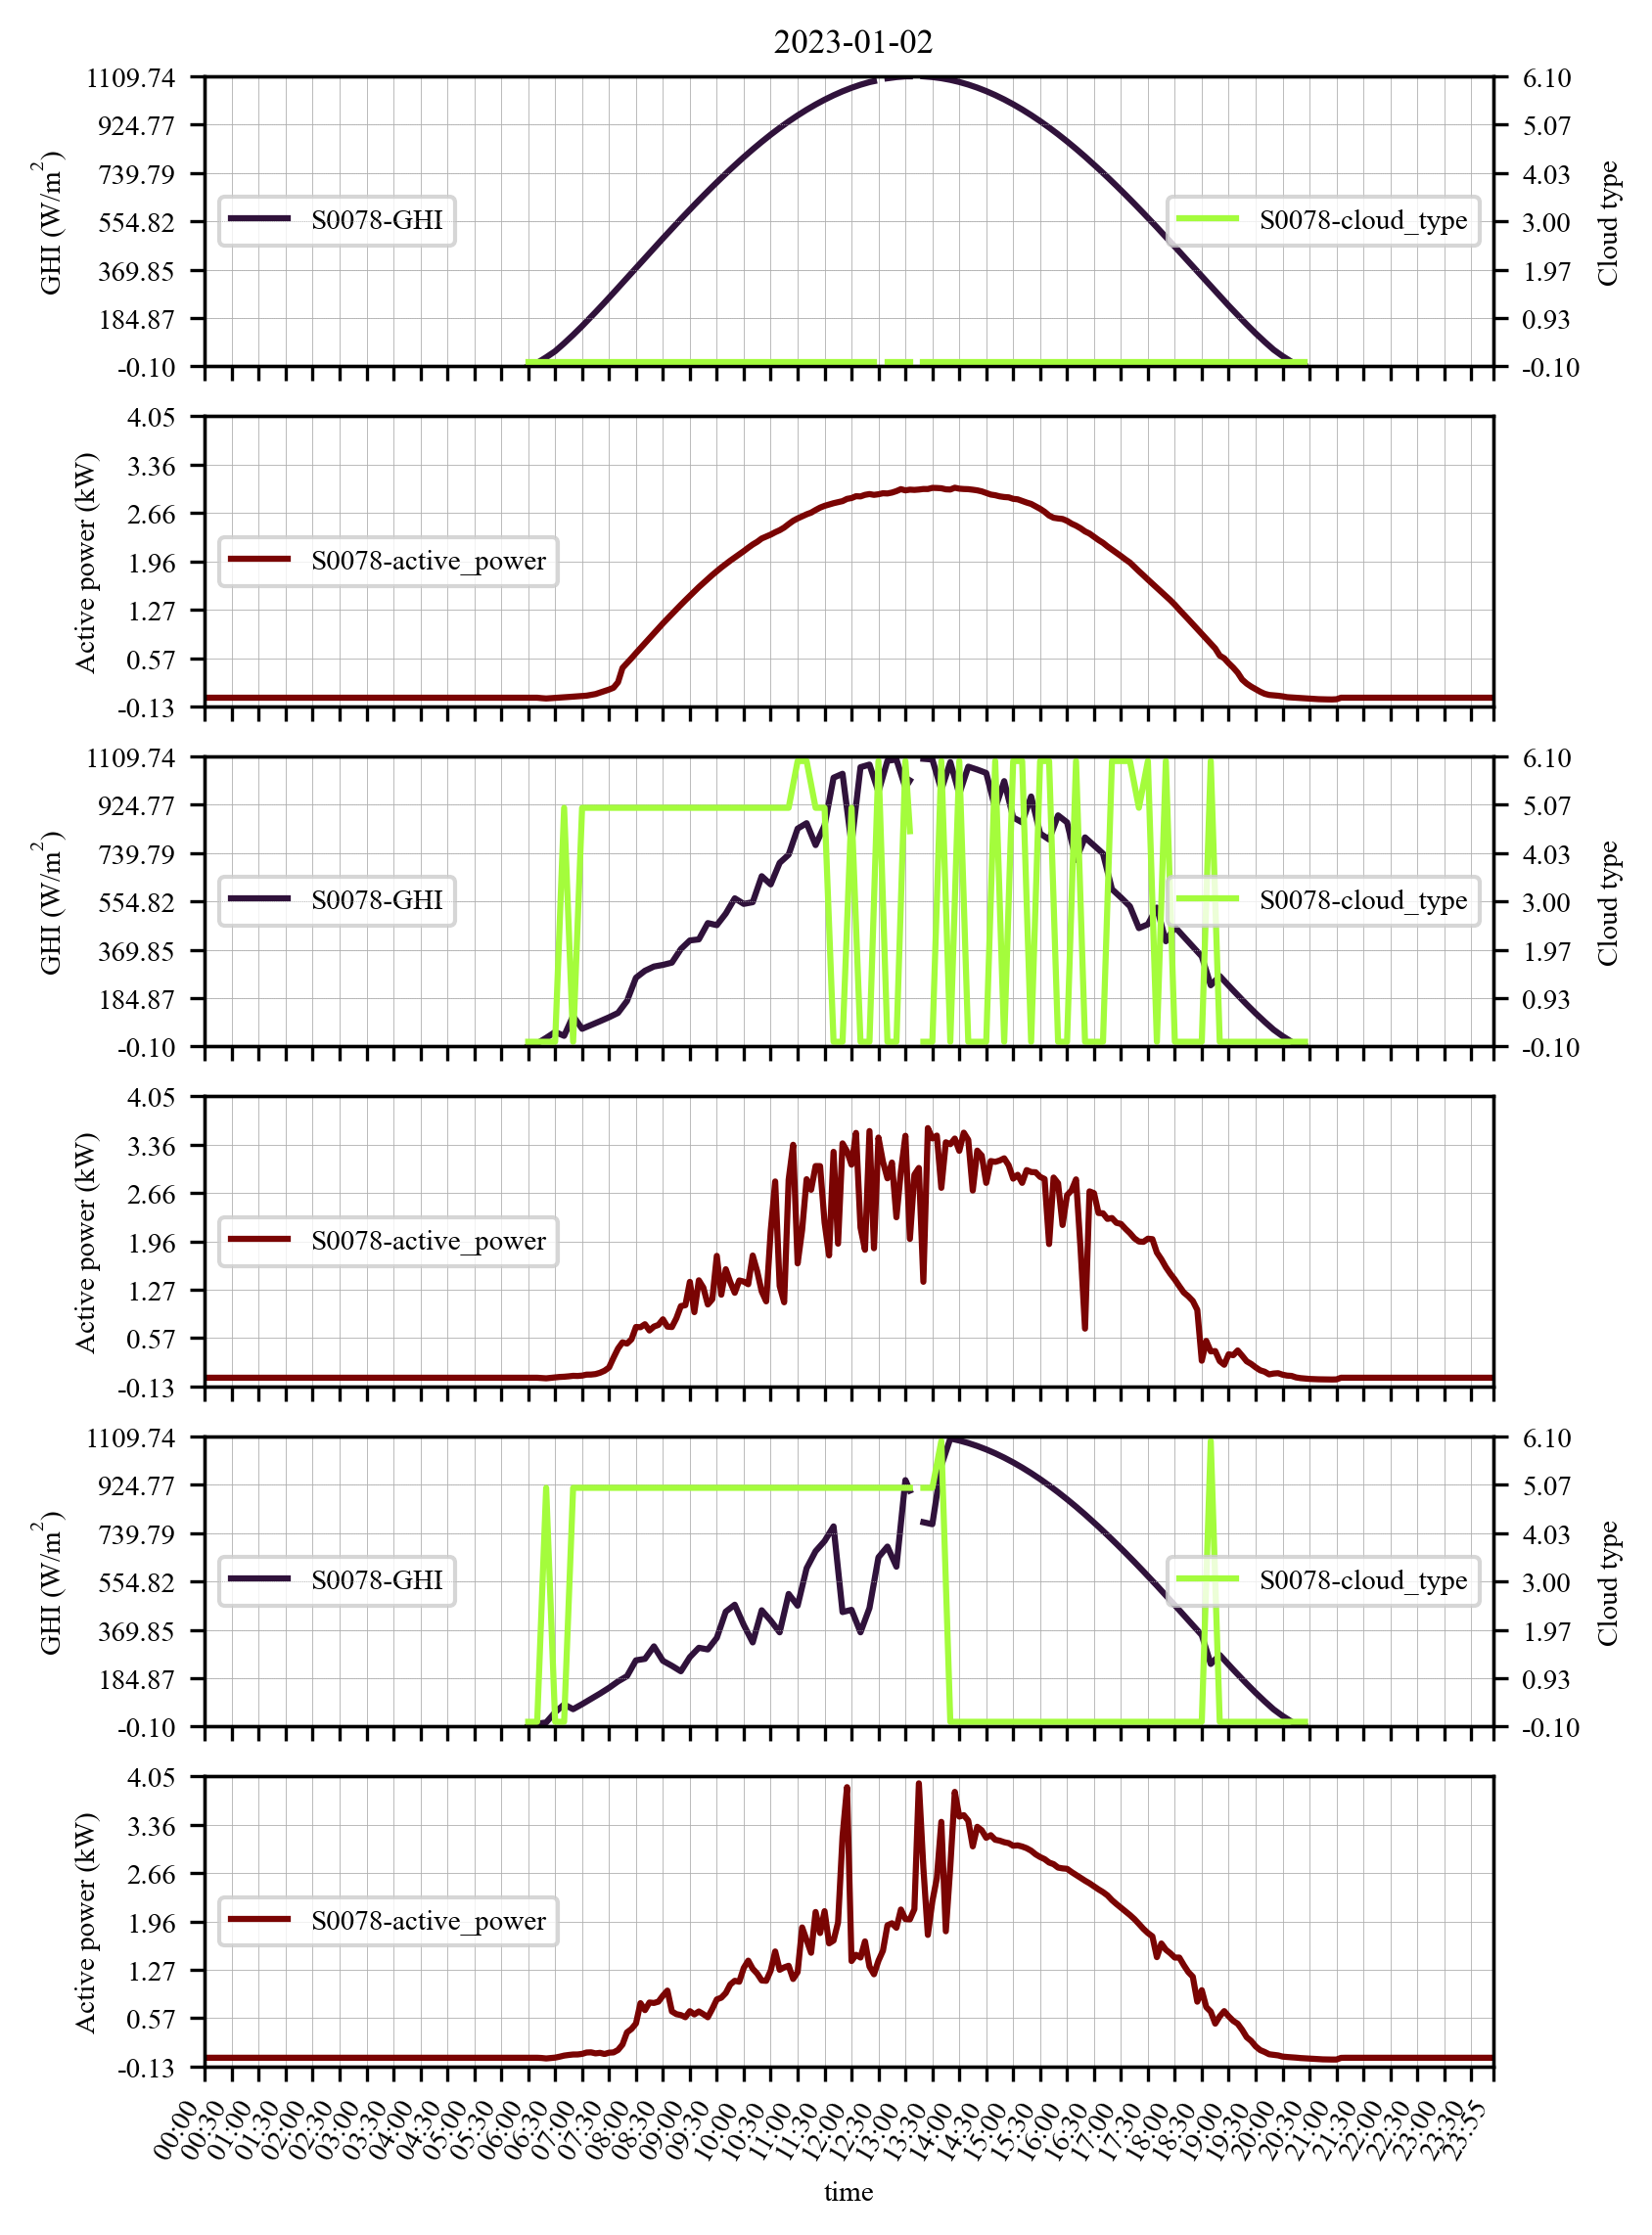

In [38]:
df8 = df5.copy()
df8 = df8[df8["edp_site_id"].isin(df8["edp_site_id"].unique()[2:3])]
df8 = df8.merge(solar, on=["time", "postcode"], how="left")
df8 = (
    df8.sort_values(["postcode", "time"])
    .groupby("postcode")
    .apply(
        lambda group: (
            group.set_index("time").interpolate(method="time", limit=1).reset_index()
        )
    )
    .reset_index(drop=True)
)

start_time = "2023-01-02 00:00:00+1030"  # In sydney local time
end_time = "2023-01-05 00:00:00+1030"  # In sydney local time

num_ticks = 2 * 24 + 1
save_as = "Figures/Solar_clouds_active_power.jpeg"
x_label = "time"
y_labels = [
    "GHI ($\mathdefault{W/m^2}$)",
    "Cloud type",
    "Active power (kW)",
]
plt_config = {
    "GHI": [0, 0, "-", None, None],
    "cloud_type": [0, 1, "-", None, None],
    # 'DNI': [0, 0, '-', None, None],
    "active_power": [1, 0, "-", None, None],
}
color_nights = False
# color_by = 'group'
color_by = "attribute"
ax_digit = "1.2f"
a = my_plot4(
    start_time,
    end_time,
    df8,
    plt_config=plt_config,
    ax_digit=ax_digit,
    group_attr="edp_site_id",
    time_attr="time",
    color_nights=color_nights,
    cmap="turbo",
    figsize=[14 / 2.54, 1.25],
    same_scale=1,
    fontsize=7,
    fontname="Times New Roman",
    plot_total=False,
    plot_total_func=["sum", [lambda x: max(x), "max"]],
    num_ticks=num_ticks,
    num_yticks=7,
    dpi=300,
    x_format="%H:%M",
    legend_loc=["center left", "center right", "center left"],
    x_label=x_label,
    y_labels=y_labels,
    color_by=color_by,
    plot_period=np.timedelta64(1, "D"),
    save_as=save_as,
    hspace=0,
    rotation=60,
    step=0,
    gridwidth=[0.2, 0.2],
    legend_join="-",
    title="",
    legend_i=0,
    title_i=0,
    only1title=1,
    onlyntime=1,
)
a.do()